In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os
print(os.getcwd())
print(os.listdir("."))

/home/akarimzadeh/Solar_ai_project/solar_ai_project/notebooks
['Untitled.ipynb', '.ipynb_checkpoints']


In [3]:
print(os.path.exists(
    "../data/Timeseries_50.776_6.084_SA3_1kWp_crystSi_14_35deg_0deg_2023_2023.csv"
))

True


In [4]:


df = pd.read_csv(
    "../data/Timeseries_50.776_6.084_SA3_1kWp_crystSi_14_35deg_0deg_2023_2023.csv",skiprows=10
)

df.head()

,time,P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int
0,20230101:0010,0.0,0.0,0.0,0.0,0.0,14.06,8.48,0.0
1,20230101:0110,0.0,0.0,0.0,0.0,0.0,13.75,8.41,0.0
2,20230101:0210,0.0,0.0,0.0,0.0,0.0,13.52,8.28,0.0
3,20230101:0310,0.0,0.0,0.0,0.0,0.0,13.38,8.07,0.0
4,20230101:0410,0.0,0.0,0.0,0.0,0.0,13.18,8.07,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8769 entries, 0 to 8768
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    8769 non-null   object 
 1   P       8761 non-null   object 
 2   Gb(i)   8760 non-null   float64
 3   Gd(i)   8760 non-null   float64
 4   Gr(i)   8760 non-null   float64
 5   H_sun   8760 non-null   float64
 6   T2m     8760 non-null   float64
 7   WS10m   8760 non-null   float64
 8   Int     8760 non-null   float64
dtypes: float64(7), object(2)
memory usage: 616.7+ KB


In [6]:
df.isna().sum()

time     0
P        8
Gb(i)    9
Gd(i)    9
Gr(i)    9
H_sun    9
T2m      9
WS10m    9
Int      9
dtype: int64

In [7]:
df = df.dropna()
df.isna().sum()

time     0
P        0
Gb(i)    0
Gd(i)    0
Gr(i)    0
H_sun    0
T2m      0
WS10m    0
Int      0
dtype: int64

In [8]:
df["time"] = pd.to_datetime(df["time"], format = '%Y%m%d:%H%M')
df.tail()

,time,P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int
8755,2023-12-31 19:10:00,0.0,0.0,0.0,0.0,0.0,6.99,7.31,0.0
8756,2023-12-31 20:10:00,0.0,0.0,0.0,0.0,0.0,6.87,7.72,0.0
8757,2023-12-31 21:10:00,0.0,0.0,0.0,0.0,0.0,6.60,7.72,0.0
8758,2023-12-31 22:10:00,0.0,0.0,0.0,0.0,0.0,6.55,7.86,0.0
8759,2023-12-31 23:10:00,0.0,0.0,0.0,0.0,0.0,6.37,7.72,0.0


In [9]:
df["P"].sample(10)

4628       0.0
4746     33.39
2287    108.32
4253     32.69
4002      35.2
8400       0.0
6169       0.0
2822    527.64
8693       0.0
6264       0.0
Name: P, dtype: object

In [10]:
df["P"] = pd.to_numeric(df["P"], errors="coerce")
df["P"].dtype

dtype('float64')

In [11]:

df["Hour"] = df["time"].dt.hour
df["month"] = df["time"].dt.month
df["day_of_year"] = df["time"].dt.dayofyear
df.head()

,time,P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int,Hour,month,day_of_year
0,2023-01-01 00:10:00,0.0,0.0,0.0,0.0,0.0,14.06,8.48,0.0,0,1,1
1,2023-01-01 01:10:00,0.0,0.0,0.0,0.0,0.0,13.75,8.41,0.0,1,1,1
2,2023-01-01 02:10:00,0.0,0.0,0.0,0.0,0.0,13.52,8.28,0.0,2,1,1
3,2023-01-01 03:10:00,0.0,0.0,0.0,0.0,0.0,13.38,8.07,0.0,3,1,1
4,2023-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,13.18,8.07,0.0,4,1,1


In [12]:
df = df.rename(columns={
    "P": "power",
    "Gb(i)": "direct_irradiance",
    "Gd(i)": "diffuse_irradiance",
    "Gr(i)": "reflected_irradiance",
    "H_sun": "sun_elevation",
    "T2m": "temperature",
    "WS10m": "wind_speed",
    "Int": "irradiance_index"
})
df.head()

,time,power,direct_irradiance,diffuse_irradiance,reflected_irradiance,sun_elevation,temperature,wind_speed,irradiance_index,Hour,month,day_of_year
0,2023-01-01 00:10:00,0.0,0.0,0.0,0.0,0.0,14.06,8.48,0.0,0,1,1
1,2023-01-01 01:10:00,0.0,0.0,0.0,0.0,0.0,13.75,8.41,0.0,1,1,1
2,2023-01-01 02:10:00,0.0,0.0,0.0,0.0,0.0,13.52,8.28,0.0,2,1,1
3,2023-01-01 03:10:00,0.0,0.0,0.0,0.0,0.0,13.38,8.07,0.0,3,1,1
4,2023-01-01 04:10:00,0.0,0.0,0.0,0.0,0.0,13.18,8.07,0.0,4,1,1


In [13]:
df = df.drop(columns=["irradiance_index"])

## Data Analyse

### 1. How does solar production vary during the day?

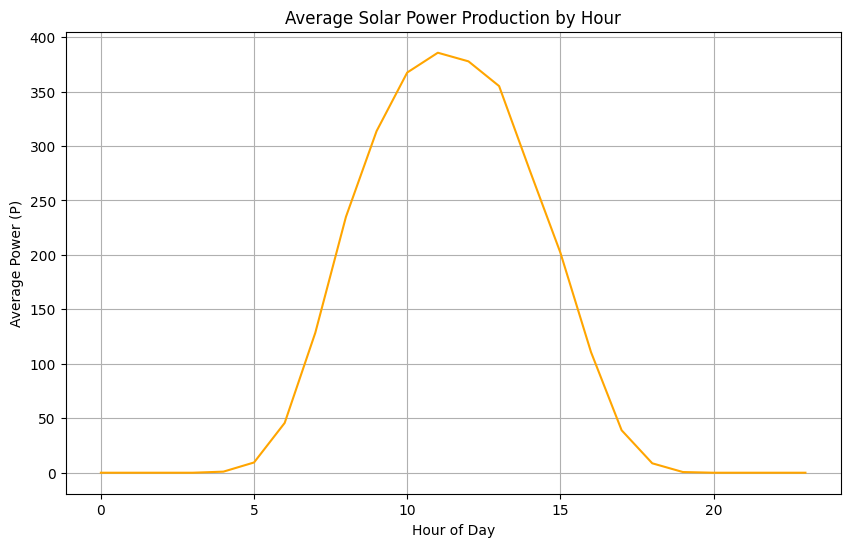

In [14]:
df.groupby(df["Hour"])["power"].mean().plot(figsize=(10,6), color = "orange")
plt.title("Average Solar Power Production by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power (P)")
plt.grid(True)
plt.show()

### Monthly production
#### *How much solar power does Aachen produce per month in avarge?*

<Axes: xlabel='month'>

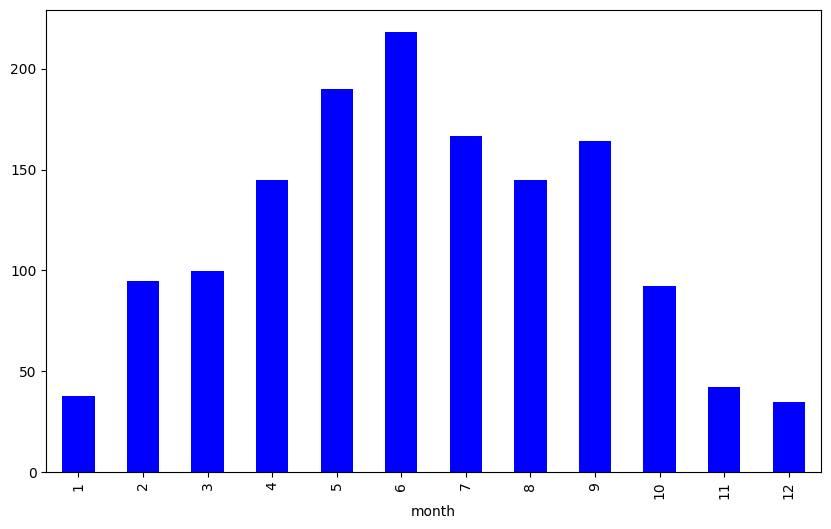

In [15]:
df.groupby("month")["power"].mean().plot( kind = "bar", figsize=(10,6), color= "blue")

### Solar Power: January vs June in Aachen

The figure compares average hourly solar power production in January and June. June shows a longer production period and higher peak output due to increased daylight hours and solar irradiance.

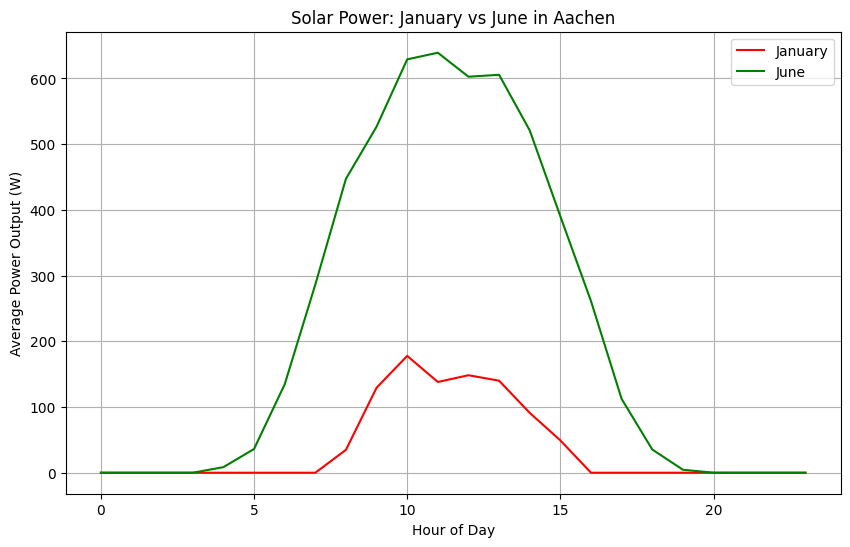

In [16]:
df_Jan = df[df["month"]== 1].groupby("Hour")["power"].mean()
df_June= df[df["month"]==6].groupby("Hour")["power"].mean()   
plt.figure(figsize=(10,6))
plt.plot(df_Jan.index, df_Jan.values, label="January", color ="red")
plt.plot(df_June.index, df_June.values, label="June", color="green")

plt.title("Solar Power: January vs June in Aachen")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Output (W)")
plt.legend()
plt.grid(True)

plt.show()

<Axes: >

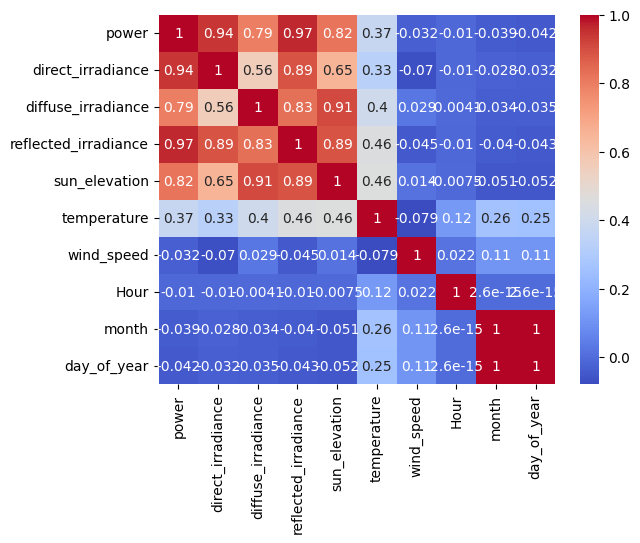

In [17]:

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

### Correlation Analysis

Solar power output is strongly correlated with solar irradiance variables and sun elevation. Direct irradiance (0.94), reflected irradiance (0.97), and sun elevation (0.82) show the strongest relationships with power production, confirming that sunlight availability is the primary driver of photovoltaic performance.

Temperature exhibits a moderate positive correlation (0.37), while wind speed has almost no relationship with power output. Several irradiance variables are also highly correlated with one another, indicating potential multicollinearity within the dataset.

In [18]:
X = df[
    [
        "direct_irradiance",
        "diffuse_irradiance",
        "reflected_irradiance",
        "sun_elevation",
        "temperature",
        "wind_speed",
        "Hour",
        "month"
    ]
]

y = df["power"]

In [19]:
from sklearn.model_selection import train_test_split

train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7008, 8)
(1752, 8)
(7008,)
(1752,)


In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

direct_irradiance       0.813455
reflected_irradiance    0.150737
diffuse_irradiance      0.023666
sun_elevation           0.009860
temperature             0.000989
Hour                    0.000617
month                   0.000401
wind_speed              0.000275
dtype: float64


In [23]:
df.columns

Index(['time', 'power', 'direct_irradiance', 'diffuse_irradiance',
       'reflected_irradiance', 'sun_elevation', 'temperature', 'wind_speed',
       'Hour', 'month', 'day_of_year'],
      dtype='object')

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 1.75
RMSE: 5.01
R²: 0.9977


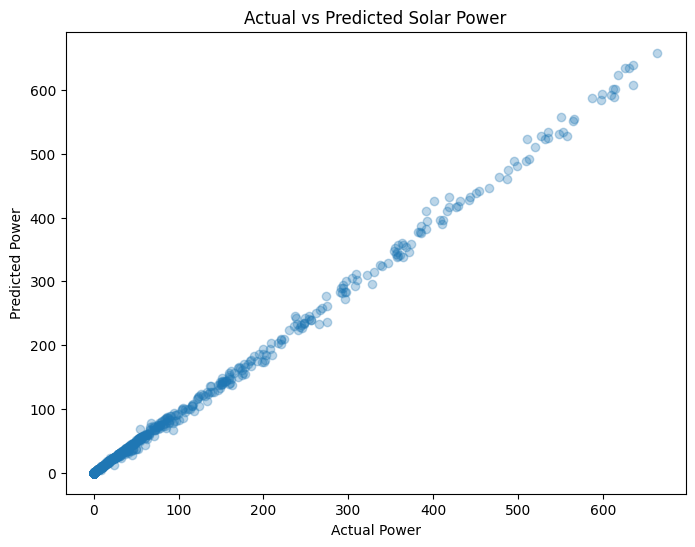

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Solar Power")

plt.show()

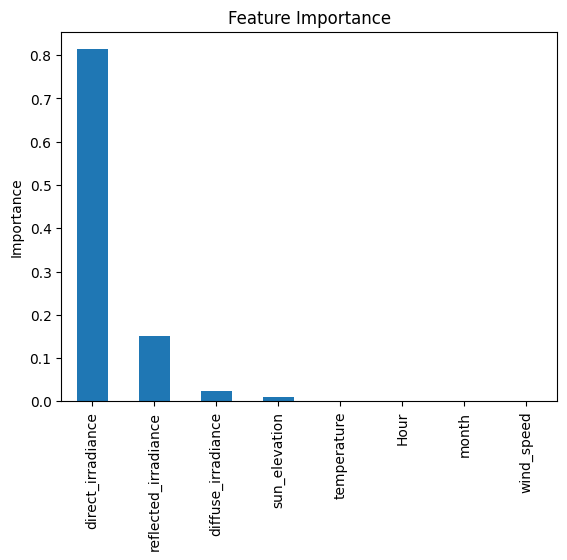

In [27]:
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

### *But — this model basically learned:

"more sun = more power"

...and not much else. It found irradiance so useful that it ignored temperature, even though temperature genuinely affects panel efficiency in reality.*

                   direct_irradiance  temperature
direct_irradiance           1.000000     0.328139
temperature                 0.328139     1.000000


<Axes: xlabel='direct_irradiance', ylabel='temperature'>

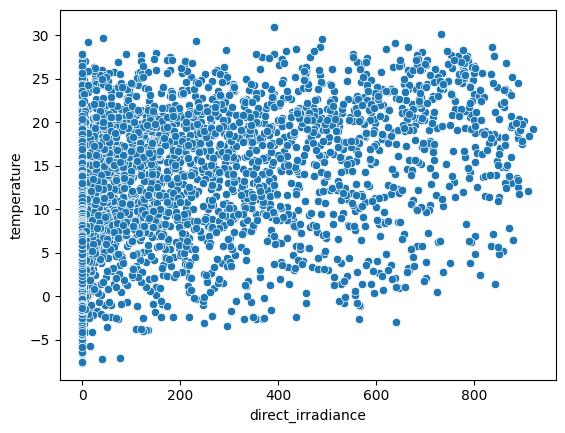

In [32]:
import seaborn as sns

# Check correlation
print(df[['direct_irradiance', 'temperature']].corr())

# Visualize
sns.scatterplot(x="direct_irradiance", y='temperature', data=df)